# 01 — Data Audit

Audit of candidate training datasets for the NutriScan v1 classifier.

**Questions this notebook answers:**
1. What classes does each source provide, and how many images per class?
2. How bad is the class imbalance?
3. Which classes overlap between sources (merge candidates)?
4. Are the images usable (resolution, corrupt files)?
5. Does `ml/labels.yaml` have enough data per class to freeze the v1 label set?

Datasets are expected under `ml/data/raw/` (git-ignored), one folder per source,
each containing class subfolders of images (extracted, not archives).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml
from PIL import Image

sns.set_theme(style="whitegrid")

ML_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path("ml")
RAW = ML_DIR / "data" / "raw"
LABELS_FILE = ML_DIR / "labels.yaml"
IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp"}

spec = yaml.safe_load(LABELS_FILE.read_text())
labels = set(spec["classes"])
print(f"Label set: {len(labels)} classes (status: {spec['status']})")
print(f"Raw data dir: {RAW.resolve()}")

Label set: 59 classes (status: frozen)
Raw data dir: D:\machine_learning_project\ml\data\raw


## 1. Discover sources and count images per class

In [2]:
def normalize(name: str) -> str:
    """Normalize a class-folder name for cross-source comparison."""
    return name.strip().lower().replace(" ", "_").replace("-", "_")


def find_class_dirs(source_dir: Path) -> dict[str, list[Path]]:
    """Map class name -> all dirs holding its images (handles train/val/test splits)."""
    candidates: dict[str, list[Path]] = {}
    for d in sorted(source_dir.rglob("*")):
        if not d.is_dir():
            continue
        has_images = any(f.suffix.lower() in IMG_EXTS for f in d.iterdir() if f.is_file())
        if has_images:
            candidates.setdefault(normalize(d.name), []).append(d)
    return candidates


rows = []
sources = [d for d in RAW.iterdir() if d.is_dir()] if RAW.exists() else []
print(f"Sources found: {[s.name for s in sources]}")
for src in sources:
    for cls, cdirs in find_class_dirs(src).items():
        n = sum(1 for cdir in cdirs for f in cdir.iterdir() if f.suffix.lower() in IMG_EXTS)
        rows.append({"source": src.name, "class": cls, "n_images": n, "n_dirs": len(cdirs)})

df = pd.DataFrame(rows)
if df.empty:
    raise SystemExit("No datasets found under ml/data/raw — extract the downloads first.")
print(
    f"{df['source'].nunique()} sources, {df['class'].nunique()} distinct classes, "
    f"{df['n_images'].sum():,} images total"
)
df.groupby("source").agg(classes=("class", "nunique"), images=("n_images", "sum"))

Sources found: ['food-101', 'food-classification', 'fruits-vegetables', 'indian-food', 'indian-food-20']


5 sources, 235 distinct classes, 122,819 images total


,classes,images
source,,
food-101,101,101000
food-classification,6,7725
fruits-vegetables,36,3825
indian-food,80,4000
indian-food-20,20,6269


## 2. Class imbalance

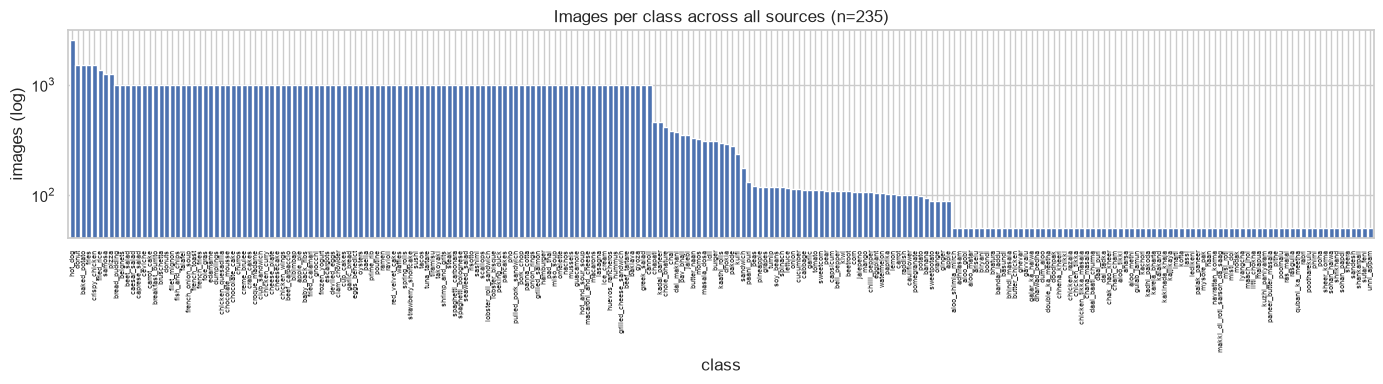

median 293 · min 50 · max 2548
classes with <150 images: 113


In [3]:
per_class = df.groupby("class")["n_images"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
per_class.plot.bar(ax=ax, width=0.9)
ax.set_yscale("log")
ax.set_ylabel("images (log)")
ax.set_title(f"Images per class across all sources (n={len(per_class)})")
ax.tick_params(axis="x", labelsize=5)
plt.tight_layout()
plt.show()

print(f"median {per_class.median():.0f} · min {per_class.min()} · max {per_class.max()}")
print(f"classes with <150 images: {(per_class < 150).sum()}")

## 3. Overlap between sources

In [4]:
overlap = (
    df.groupby("class")["source"]
    .agg(["nunique", lambda s: ", ".join(sorted(set(s)))])
    .rename(columns={"nunique": "n_sources", "<lambda_0>": "sources"})
)
multi = overlap[overlap["n_sources"] > 1].sort_values("n_sources", ascending=False)
print(f"{len(multi)} classes appear in more than one source (dedupe/merge needed):")
multi

8 classes appear in more than one source (dedupe/merge needed):


,n_sources,sources
class,,
chapati,2,"indian-food, indian-food-20"
dal_makhani,2,"indian-food, indian-food-20"
fried_rice,2,"food-101, indian-food-20"
hot_dog,2,"food-101, food-classification"
jalebi,2,"indian-food, indian-food-20"
kadai_paneer,2,"indian-food, indian-food-20"
pizza,2,"food-101, indian-food-20"
samosa,2,"food-101, indian-food-20"


## 4. Image quality — resolution sample & corrupt-file check

In [5]:
import random

random.seed(42)
sample_stats, corrupt = [], []
for src in sources:
    files = [f for f in Path(src).rglob("*") if f.suffix.lower() in IMG_EXTS]
    for f in random.sample(files, min(300, len(files))):
        try:
            with Image.open(f) as im:
                w, h = im.size
            sample_stats.append(
                {"source": src.name, "width": w, "height": h, "min_side": min(w, h)}
            )
        except Exception:
            corrupt.append(str(f))

q = pd.DataFrame(sample_stats)
print(f"corrupt files in sample: {len(corrupt)}")
q.groupby("source")["min_side"].describe()[["count", "min", "25%", "50%", "max"]]

corrupt files in sample: 0


,count,min,25%,50%,max
source,,,,,
food-101,300.0,285.0,384.00,512.0,512.0
food-classification,300.0,100.0,183.00,183.0,2700.0
fruits-vegetables,300.0,133.0,627.00,900.0,4756.0
indian-food,300.0,128.0,190.75,375.0,3025.0
indian-food-20,300.0,164.0,422.00,565.0,3294.0


## 5. Coverage of the v1 label set

In [6]:
# Folder-name -> label aliases live in labels.yaml (single source of truth,
# also used by Day 5 prepare_data.py).
aliases = spec.get("aliases", {})
backfill = set(spec.get("backfill", []))

df["label"] = df["class"].map(lambda c: aliases.get(c, c))
avail = df[df["label"].isin(labels)].groupby("label")["n_images"].sum()

covered = avail[avail >= 150]
thin = avail[avail < 150]
missing = sorted(labels - set(avail.index))

print(f"covered (>=150 imgs): {len(covered)} -> {sorted(covered.index)}\n")
print(f"thin (<150 imgs): {len(thin)} -> {sorted(thin.index)}\n")
print(f"missing entirely: {len(missing)} -> {missing}\n")
print(f"thin, flagged for scraping backfill: {sorted(set(thin.index) & backfill)}\n")
print(f"thin, NOT flagged (produce, ok with augmentation): {sorted(set(thin.index) - backfill)}")

covered (>=150 imgs): 29 -> ['burger', 'capsicum', 'chicken_curry', 'chole_bhature', 'dal_makhani', 'dhokla', 'donut', 'dosa', 'french_fries', 'fried_chicken', 'fried_rice', 'hot_dog', 'ice_cream', 'idli', 'jalebi', 'kadai_paneer', 'kathi_roll', 'kulfi', 'masala_chai', 'momos', 'naan', 'omelette', 'pakora', 'pav_bhaji', 'pizza', 'roti', 'samosa', 'sandwich', 'spring_roll']

thin (<150 imgs): 30 -> ['aloo_gobi', 'apple', 'banana', 'bhindi_masala', 'butter_chicken', 'carrot', 'cauliflower', 'chana_masala', 'chicken_biryani', 'cucumber', 'dal_tadka', 'gajar_halwa', 'grapes', 'gulab_jamun', 'kachori', 'lassi', 'mango', 'onion', 'orange', 'palak_paneer', 'paneer_butter_masala', 'pani_puri', 'pineapple', 'poha', 'pomegranate', 'potato', 'rasgulla', 'spinach', 'tomato', 'watermelon']

missing entirely: 0 -> []

thin, flagged for scraping backfill: ['aloo_gobi', 'bhindi_masala', 'butter_chicken', 'chana_masala', 'chicken_biryani', 'dal_tadka', 'gajar_halwa', 'gulab_jamun', 'kachori', 'lassi', 

## 6. Decisions (2026-07-18)

**v1 label set frozen at 59 classes** in `ml/labels.yaml` (was a 70-class draft; 24 dropped, 13 added).

**Sources (5, all kept):**

| source | classes | images | role |
|---|---|---|---|
| food-101 | 101 | 101,000 | Western base (10 classes used) + chicken_curry / fried_rice / samosa boosts |
| indian-food-20 (`l33tc0d3r/indian-food-classification`) | 20 | 6,269 | core Indian staples, ~260–415 imgs/class |
| indian-food (80-class) | 80 | 4,000 | only 50 imgs/class, mostly obscure regional sweets — contributes boosts + the backfill classes |
| fruits-vegetables | 36 | 3,825 | produce, ~90–120 imgs/class |
| food-classification (fast-food) | 6 | 7,725 | downloaded by mistake (wrong "Food Classification" dataset), but redeemed: fries / hot_dog / donut / sandwich / fried_chicken |

**Key audit findings:**
- The 80-class Indian dataset has **no dosa, idli, samosa, momos or roti** and only 50 imgs/class — it cannot carry the Indian domain alone. The 20-class `indian-food-20` set fills exactly that gap (fetched during the audit after discovering the wrong dataset had been downloaded).
- Coverage of the frozen set: **29 classes ≥150 imgs · 30 thin · 0 missing**.
- **Dropped 24 draft classes with zero usable images** (vada_pav, paratha, upma, uttapam, medu_vada, tandoori_chicken, fish_curry, egg_curry, rajma, khichdi, malai_kofta, baingan_bharta, misal_pav, poori_bhaji, puri, jeera_rice, veg_pulao, kheer, barfi, ladoo, guava, papaya, litchi, strawberry) — deferred to v2 via scraping + the FR-15/16 user-feedback loop.
- **Added 13 classes the data supports**: pani_puri, kathi_roll, kulfi (indian-food-20) and 10 Western dishes (pizza, burger, french_fries, hot_dog, donut, sandwich, fried_chicken, ice_cream, omelette, spring_roll) per SRS §2.1 "Western dishes supported via base datasets".
- **15 dishes kept at ~50–140 imgs** are listed under `backfill:` in labels.yaml — curated scraping (SRS ML-1, data-scarcity risk mitigation) must raise them to ≥150 before the Day 5 frozen split; any still short then are excluded from the split (the labels file itself stays frozen).
- 15 produce classes at 88–119 imgs are acceptable with augmentation (visually distinctive, low intra-class variance).
- Aliases moved into `labels.yaml` (`aliases:`) — single source of truth for this notebook and Day 5 `prepare_data.py`.

**Quality issues for `prepare_data.py` (Day 5):**
- No corrupt files in the 1,500-image sample; still guard with a try/except decode pass over the full corpus.
- Min-resolution filter: drop images with min side < 128 px (fast-food set 25th percentile is 183 px — expect some loss there).
- Dedupe: 8 raw class-folder names appear in ≥2 sources (chapati, dal_makhani, jalebi, kadai_paneer, fried_rice, samosa, pizza, hot_dog); also run near-duplicate detection (perceptual hash) across sources before splitting.
- Nested folders (`Indian Food Images/Indian Food Images/`) and per-source train/val/test splits are handled here by recursive discovery — prepare_data must do the same and re-split from the merged pool.